# Papalexi ECCITE-seq demo

An interactive tour of one complete `petrubseq-protein` run on the bundled Papalexi ECCITE-seq subset. The pipeline is run by the CLI (section 2); this notebook only loads and displays what that run produced. `report.html` in the run directory is the complete, automatically generated report.

## 1. Dataset

Papalexi E. *et al.*, Nat Genet 53:322 (2021), GEO GSE153056, pooled ECCITE-seq screen in IFN-γ stimulated THP-1 cells. The repository bundles a deterministic 1,800-cell subset (`demo/data/papalexi_eccite/`): RNA (18,649 genes, raw UMI counts), guide UMI counts (111 sgRNAs: 25 gene targets, 9 non-targeting `NT`, 1 eGFP), four ADTs (CD86, PD-L1 `PDL1`, PD-L2 `PDL2`, TIM-3 `CD366`), three hashed samples over eight lanes. All cells are IFN-γ stimulated; there are no isotype controls. It is a demonstration subset, not a reanalysis of the paper.

## 2. Run the pipeline

```bash
conda activate petrubseq-protein
petrubseq-protein run --config config/demo_papalexi.yaml
```

Output is written to `${RESULTS_ROOT}/demo/papalexi_eccite/` (`../results/` next to the repository, or `PETRUBSEQ_RESULTS_ROOT`). The config enables clustering (default), the perturbation-effect analyses and the protein analyses:

In [1]:
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

REPO = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
RESULTS = Path(os.environ.get("PETRUBSEQ_RESULTS_ROOT", REPO.parent / "results")) / "demo" / "papalexi_eccite"
T = RESULTS / "tables"
pd.set_option("display.width", 200, "display.max_columns", 30)

cfg = (REPO / "config" / "demo_papalexi.yaml").read_text()
print(cfg[cfg.index("analysis:"):])

analysis:
  perturbation_effects:
    enabled: true
    control_classes: [non_targeting]     # the NT guides; eGFP (transgene) cells are neither perturbed nor control
    target_gene_map:
      PDL1: CD274                        # dataset label -> RNA gene symbol (every other target label is its gene symbol)
    top_n_report: 12
    ps:
      top_n_genes: 100                   # reference defaults (PS_python / pertps)
      scale_factor: 3.0
      ps_threshold: 0.5
      min_cells_per_target: 10
    lochness:
      n_neighbors: 300                   # reference default; capped at 0.1 x 1,800 = 180 neighbours for the demo (recorded)
      max_k_fraction: 0.1
      n_pcs: 20
      n_permutations: 200
    modules:
      min_cells_per_perturbation: 20     # reference default: targets with >= 20 single-guide cells
      n_programs: 4                      # reference default
      n_modules: 9                       # reference default
      log2fc_pseudocount: 1.0            # generic defaul

## 3. Load processed data

In [2]:
import anndata as ad

adata = ad.read_h5ad(RESULTS / "processed" / "papalexi_eccite_demo_processed.h5ad")
u = adata.uns["petrubseq_protein"]
print(f"cells {adata.n_obs}, genes {adata.n_vars}, proteins {adata.obsm['protein'].shape[1]}, guides {adata.obsm['guide_counts'].shape[1]}, "
      f"targets {adata.obs.loc[adata.obs['perturbation_class'] == 'single_targeting', 'target'].nunique()}, Leiden clusters {adata.obs['leiden'].nunique()}")
print("obs:", [c for c in adata.obs.columns if c in ("condition", "sample", "lane", "perturbation", "perturbation_class", "guide", "target", "leiden", "ps_score", "ps_quadrant", "lochness_self")])
print("obsm:", list(adata.obsm))
print("uns tables:", [k for k in adata.uns if k not in ("petrubseq_protein", "pca", "pca_protein", "rna", "protein", "umap", "hvg", "leiden", "neighbors")])

cells 1800, genes 16642, proteins 4, guides 111, targets 25, Leiden clusters 10
obs: ['condition', 'sample', 'lane', 'guide', 'target', 'perturbation', 'perturbation_class', 'ps_score', 'ps_quadrant', 'lochness_self', 'leiden']
obsm: ['X_pca', 'X_pca_protein', 'X_umap_protein', 'X_umap_rna', 'guide_counts', 'lochness', 'program_activity', 'protein', 'protein_counts', 'ps_scores', 'ps_scores_raw']
uns tables: ['gene_programs', 'guide_features', 'perturbation_cluster_enrichment', 'perturbation_effect_matrix', 'perturbation_modules', 'perturbation_summary', 'protein_effects', 'protein_features', 'ps_signatures']


## 4. QC

Filtering steps, perturbation classes, target coverage and the protein panel. The report has the full before/after QC figures.

In [3]:
pd.read_csv(T / "qc_filtering_steps.csv")[["step", "category", "threshold", "cells_before", "cells_after", "cells_removed", "genes_before", "genes_after"]]

,step,category,threshold,cells_before,cells_after,cells_removed,genes_before,genes_after
0,input,input,-,1800,1800,0,18649,18649
1,prefilter_min_genes,prefilter,genes detected >= 200,1800,1800,0,18649,18649
2,prefilter_min_cells_per_gene,prefilter,cells with gene >= 3,1800,1800,0,18649,16642
3,rna_min_genes,rna,genes detected >= 500,1800,1800,0,16642,16642
4,rna_max_pct_mt,rna,% mitochondrial <= 20.0,1800,1800,0,16642,16642
5,final,final,-,1800,1800,0,16642,16642


In [4]:
adata.obs["perturbation_class"].value_counts().to_frame("cells")

,cells
perturbation_class,
single_targeting,1516
single_control,199
ambiguous,85


In [5]:
tc = pd.read_csv(T / "target_coverage.csv")
tc.sort_values("n_cells_single_guide", ascending=False)[["target", "class", "n_guides", "n_cells_single_guide", "low_coverage"]].reset_index(drop=True)

,target,class,n_guides,n_cells_single_guide,low_coverage
0,NT,non_targeting,9,199,False
1,IFNGR1,targeting,4,102,False
2,CD86,targeting,4,98,False
3,IFNGR2,targeting,4,95,False
4,ATF2,targeting,4,92,False
5,JAK2,targeting,4,87,False
6,IRF1,targeting,4,85,False
7,MARCH8,targeting,4,81,False
8,TNFRSF14,targeting,4,79,False
9,CAV1,targeting,4,74,False


In [6]:
adata.uns["protein_features"][["role", "antibody_name", "gene_symbol", "in_counts", "used_in_embedding", "annotation_source"]]

,role,antibody_name,gene_symbol,in_counts,used_in_embedding,annotation_source
protein,,,,,,
CD86,target,CD86,CD86,True,True,input_features+feature_table
PDL1,target,PDL1,CD274,True,True,input_features+feature_table
PDL2,target,PDL2,PDCD1LG2,True,True,input_features+feature_table
CD366,target,CD366,HAVCR2,True,True,input_features+feature_table


In [7]:
pi = u["perturbations"]
print("assignment source:", pi["assignment"]["effective_source"], "| rule:", pi["assignment"]["guide_calling"]["method"], pi["assignment"]["guide_calling"]["dominant_rule"])
adata.obs[["guide_total_counts", "n_guides_detected", "guide_top_count", "guide_second_count"]].describe().round(1).T

assignment source: guide_counts | rule: dominant {'ambiguous': 85, 'assigned': 1715, 'unassigned': 0}


,count,mean,std,min,25%,50%,75%,max
guide_total_counts,1800.0,320.4,295.0,116.0,147.0,209.5,376.0,3621.0
n_guides_detected,1800.0,2.5,2.7,1.0,1.0,1.0,3.0,29.0
guide_top_count,1800.0,196.1,279.5,6.0,29.0,90.0,254.2,3493.0
guide_second_count,1800.0,8.2,31.4,1.0,2.0,2.0,4.0,670.0


## 5. RNA representation and Leiden clustering

PCA, the 15-neighbour graph and UMAP are stored in the object; Leiden (resolution 1.0) was run on that graph. Coordinates below are the stored ones.

In [8]:
cs = u["analysis"]["cell_states"]["clustering"]
print({k: cs[k] for k in ("method", "resolution", "n_clusters", "min_cluster_size", "max_cluster_size")})
summ = pd.read_csv(T / "cell_states" / "cluster_summary.csv")
summ[["cluster", "n_cells", "n_single_targeting", "n_single_control", "n_ambiguous", "top_sample", "top_sample_share", "depth_ratio_to_overall", "flags"]].fillna("")

{'method': 'Leiden (igraph backend via scanpy.tl.leiden) on the existing RNA neighbour graph', 'resolution': 1.0, 'n_clusters': 10, 'min_cluster_size': 9, 'max_cluster_size': 292}


,cluster,n_cells,n_single_targeting,n_single_control,n_ambiguous,top_sample,top_sample_share,depth_ratio_to_overall,flags
0,0,165,137,21,7,rep1-tx,0.709091,1.007983,
1,1,147,117,21,9,rep3-tx,0.496599,1.031810,
2,2,292,236,22,34,rep1-tx,0.845890,0.830599,sample rep1-tx = 85% of cells (vs 38% overall); batch lanes_1-4 = 85% of cells (vs 38% overall)
3,3,222,187,31,4,rep4-tx,0.454955,1.003570,
4,4,189,185,0,4,rep4-tx,0.365079,0.939067,
5,5,216,185,25,6,rep3-tx,0.361111,1.061535,
6,6,206,174,29,3,rep3-tx,0.451456,0.977296,
7,7,240,195,29,16,rep1-tx,0.479167,1.543784,median library size 1.54 x the overall median (possible depth-driven state)
8,8,9,8,1,0,rep4-tx,0.666667,0.807333,
9,9,114,92,20,2,rep3-tx,0.526316,1.007822,


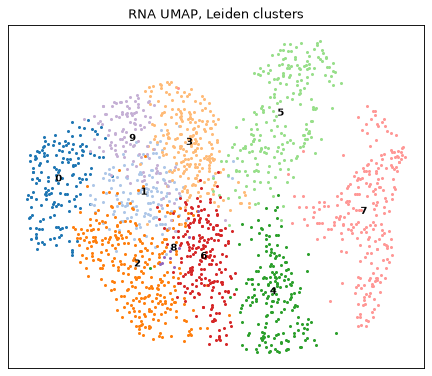

In [9]:
U = adata.obsm["X_umap_rna"]
lab = adata.obs["leiden"].astype(str)
fig, ax = plt.subplots(figsize=(5.5, 4.8))
for i, k in enumerate(adata.obs["leiden"].cat.categories):
    m = (lab == k).to_numpy()
    ax.scatter(U[m, 0], U[m, 1], s=3, color=plt.get_cmap("tab20")(i % 20), label=k)
    ax.text(U[m, 0].mean(), U[m, 1].mean(), k, fontsize=9, weight="bold", ha="center")
ax.set_xticks([]); ax.set_yticks([]); ax.set_title("RNA UMAP, Leiden clusters"); fig.tight_layout()

## 6. Perturbation × cluster enrichment

Per target and cluster: Fisher exact test of the target's single-guide cells vs non-targeting cells, BH-FDR over all pairs, guide agreement, and a Cochran–Mantel–Haenszel test stratified by hashed sample. Table from `tables/cell_states/perturbation_cluster_enrichment.csv`.

In [10]:
enr = pd.read_csv(T / "cell_states" / "perturbation_cluster_enrichment.csv")
e = u["analysis"]["cell_states"]["enrichment"]
print(f"{e['n_tests']} tests, {e['n_significant']} significant at FDR < {e['fdr_alpha']} ({e['n_significant_enriched']} enriched, {e['n_significant_depleted']} depleted); CMH significant: {e.get('n_cmh_significant')}")
print("omnibus:", {k: round(v, 4) if isinstance(v, float) else v for k, v in e["omnibus"].items()})
sig = enr[enr["significant"]]
sig[["target", "cluster", "direction", "n_target_in_cluster", "n_target_total", "n_control_in_cluster", "n_control_total", "odds_ratio", "fdr", "n_guides_supporting_direction", "n_guides_observed", "cmh_fdr"]].round(4).reset_index(drop=True)

225 tests, 11 significant at FDR < 0.05 (5 enriched, 6 depleted); CMH significant: 9
omnibus: {'chi2': 1029.0421, 'dof': 192, 'n_permutations': 1000, 'p_chi2': 0.0, 'p_permutation': 0.001, 'pct_expected_below_5': 36.0}


,target,cluster,direction,n_target_in_cluster,n_target_total,n_control_in_cluster,n_control_total,odds_ratio,fdr,n_guides_supporting_direction,n_guides_observed,cmh_fdr
0,JAK2,4,enriched,57,87,0,199,inf,0.0000,4,4,0.0000
1,IFNGR1,4,enriched,59,102,0,199,inf,0.0000,4,4,0.0000
2,IFNGR2,4,enriched,49,95,0,199,inf,0.0000,4,4,0.0000
3,STAT1,4,enriched,11,30,0,199,inf,0.0000,2,2,0.0000
4,SMAD4,2,enriched,22,54,22,199,5.5312,0.0001,2,2,0.0011
5,IFNGR2,9,depleted,0,95,20,199,0.0000,0.0134,4,4,0.0365
6,JAK2,9,depleted,0,87,20,199,0.0000,0.0213,4,4,0.0543
7,JAK2,0,depleted,0,87,21,199,0.0000,0.0213,4,4,0.0370
8,JAK2,6,depleted,2,87,29,199,0.1379,0.0342,4,4,0.0370
9,IRF1,6,depleted,2,85,29,199,0.1413,0.0342,4,4,0.0557


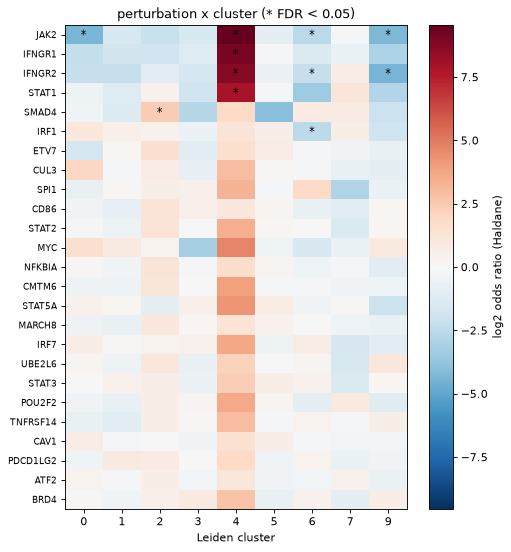

In [11]:
L = enr.pivot(index="target", columns="cluster", values="log2_or_haldane")
S = enr.pivot(index="target", columns="cluster", values="significant").fillna(False)
L = L.loc[enr.groupby("target")["fdr"].min().sort_values().index]
fig, ax = plt.subplots(figsize=(6.5, 7))
lim = float(L.abs().max().max())
im = ax.imshow(L.to_numpy(), cmap="RdBu_r", vmin=-lim, vmax=lim, aspect="auto")
for i in range(L.shape[0]):
    for j in range(L.shape[1]):
        if bool(S.loc[L.index[i], L.columns[j]]):
            ax.text(j, i, "*", ha="center", va="center")
ax.set_xticks(range(L.shape[1])); ax.set_xticklabels(L.columns); ax.set_yticks(range(L.shape[0])); ax.set_yticklabels(L.index, fontsize=8)
ax.set_xlabel("Leiden cluster"); plt.colorbar(im, ax=ax, label="log2 odds ratio (Haldane)"); ax.set_title("perturbation x cluster (* FDR < 0.05)"); fig.tight_layout()

In [12]:
# composition of the cluster with the strongest enrichments
top_cluster = sig.sort_values("fdr").iloc[0]["cluster"]
comp = pd.read_csv(T / "cell_states" / "cluster_composition_by_target.csv", index_col=0)
comp.loc[top_cluster].sort_values(ascending=False).head(8).to_frame(f"cells in cluster {top_cluster}")

,cells in cluster 4
IFNGR1,59
JAK2,57
IFNGR2,49
STAT1,11
ambiguous,4
STAT5A,2
CMTM6,2
IRF7,1


## 7. Perturbation-response score (PS)

Per cell, how much of its perturbation's transcriptional signature the cell shows (0 = like controls, 1 = the strongest response of that target). PS is max-normalized within each target, so it compares cells of one target; `auc_vs_control` / `d_vs_control` compare the separation from controls across targets.

In [13]:
ps = pd.read_csv(T / "perturbation_effects" / "ps_targets.csv")
print(f"{len(ps)} targets scored; skipped: {pd.read_csv(T / 'perturbation_effects' / 'ps_skipped.csv')[['target', 'reason']].to_dict('records')}")
ps.sort_values("auc_vs_control", ascending=False)[["target", "n_perturbed_cells", "median_ps", "q25_ps", "q75_ps", "pct_high_ps", "pct_high_ps_control", "auc_vs_control", "d_vs_control", "pct_successful_kd", "net_pct_kd"]].round(3).reset_index(drop=True)

24 targets scored; skipped: [{'target': 'CAV1', 'reason': 'target gene CAV1 expressed in 0.00% of control cells (< 1.0%)'}]


,target,n_perturbed_cells,median_ps,q25_ps,q75_ps,pct_high_ps,pct_high_ps_control,auc_vs_control,d_vs_control,pct_successful_kd,net_pct_kd
0,MYC,24,0.548,0.408,0.665,54.167,0.503,0.978,2.549,29.167,29.167
1,STAT3,39,0.477,0.397,0.642,46.154,0.000,0.970,2.375,35.897,35.897
2,STAT2,55,0.494,0.385,0.577,49.091,0.503,0.964,2.192,38.182,37.679
3,BRD4,29,0.377,0.289,0.608,34.483,0.000,0.957,2.587,34.483,34.483
4,SMAD4,54,0.463,0.344,0.634,48.148,0.000,0.956,2.473,44.444,44.444
5,SPI1,21,0.390,0.271,0.679,38.095,0.000,0.953,2.800,28.571,28.571
6,UBE2L6,43,0.450,0.294,0.576,37.209,0.503,0.942,2.145,23.256,22.753
7,IRF7,46,0.428,0.309,0.548,32.609,1.005,0.932,2.256,8.696,8.696
8,STAT5A,54,0.462,0.326,0.541,33.333,1.508,0.923,2.018,31.481,29.974
9,PDCD1LG2,53,0.430,0.270,0.538,32.075,0.000,0.921,2.024,26.415,26.415


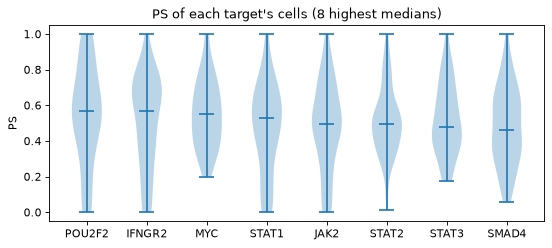

In [14]:
show = ps.sort_values("median_ps", ascending=False)["target"].head(8).tolist()
data = [adata.obs.loc[(adata.obs["target"] == t) & adata.obs["ps_score"].notna(), "ps_score"].to_numpy() for t in show]
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.violinplot(data, showmedians=True); ax.set_xticks(range(1, len(show) + 1)); ax.set_xticklabels(show); ax.set_ylabel("PS"); ax.set_title("PS of each target's cells (8 highest medians)"); fig.tight_layout()

## 8. lochNESS

Cluster-free counterpart of section 6: for each cell, the enrichment of a target among its k nearest neighbours in PCA space relative to the target's overall frequency (0 = chance). The own-cell mean says whether a target's cells sit together; a label-permutation null gives the FDR.

In [15]:
lo = pd.read_csv(T / "perturbation_effects" / "lochness_targets.csv")
li = u["analysis"]["perturbation_effects"]["lochness"]
print({k: li[k] for k in ("use_rep", "k_used", "k_capped", "n_permutations")})
lo[["target", "n_cells", "mean_lochness_in_own_cells", "delta_own_vs_control", "z_score", "fdr", "max_sample_share"]].round(3).head(12)

{'use_rep': 'X_pca', 'k_used': 180, 'k_capped': True, 'n_permutations': 200}


,target,n_cells,mean_lochness_in_own_cells,delta_own_vs_control,z_score,fdr,max_sample_share
0,IFNGR1,102,1.465,2.001,20.341,0.016,0.382
1,JAK2,87,1.427,2.045,16.434,0.016,0.379
2,SMAD4,54,1.248,1.357,12.195,0.016,0.500
3,IFNGR2,95,0.806,1.296,9.982,0.016,0.358
4,SPI1,21,0.687,0.580,3.370,0.041,0.381
5,STAT2,55,0.459,0.146,4.259,0.016,0.382
6,STAT1,30,0.441,0.838,2.608,0.050,0.433
7,CUL3,25,0.384,0.306,2.052,0.093,0.360
8,BRD4,29,0.375,0.201,2.272,0.057,0.448
9,IRF1,85,0.279,0.393,3.625,0.016,0.471


In [16]:
# cluster enrichment and lochNESS side by side (descriptive; no combined statistic)
cmp = pd.read_csv(T / "cell_states" / "cluster_enrichment_vs_lochness.csv")
cmp[["target", "n_cells", "n_clusters_significant", "top_enriched_cluster", "top_enriched_log2_or", "top_enriched_fdr", "lochness_own_mean", "lochness_delta_own_vs_control", "lochness_fdr"]].round(3).head(12)

,target,n_cells,n_clusters_significant,top_enriched_cluster,top_enriched_log2_or,top_enriched_fdr,lochness_own_mean,lochness_delta_own_vs_control,lochness_fdr
0,JAK2,87,4,4,9.555,0.000,1.427,2.045,0.016
1,IFNGR2,95,3,4,8.730,0.000,0.806,1.296,0.016
2,IFNGR1,102,1,4,9.092,0.000,1.465,2.001,0.016
3,IRF1,85,1,0,0.979,0.404,0.279,0.393,0.016
4,SMAD4,54,1,2,2.449,0.000,1.248,1.357,0.016
5,STAT1,30,1,4,7.878,0.000,0.441,0.838,0.050
6,ATF2,92,0,2,0.658,0.770,0.075,-0.068,0.177
7,BRD4,29,0,3,0.834,0.771,0.375,0.201,0.057
8,CAV1,74,0,0,0.732,0.706,0.004,-0.096,0.415
9,CD86,98,0,2,1.214,0.139,0.254,0.010,0.016


## 9. Perturbation modules

Targets clustered on the Spearman correlation of their response-gene log2FC profiles (vs non-targeting controls).

In [17]:
mods = pd.read_csv(T / "perturbation_effects" / "perturbation_modules.csv")
print(mods.groupby("module")["target"].apply(list).to_dict())
mods[["target", "module", "n_cells", "n_de_genes", "n_up", "n_down", "mean_abs_log2fc"]].round(3)

{'M1': ['MYC'], 'M2': ['SMAD4'], 'M3': ['JAK2', 'IFNGR2', 'IFNGR1', 'STAT1', 'IRF1', 'POU2F2'], 'M4': ['CUL3'], 'M5': ['BRD4'], 'M6': ['SPI1'], 'M7': ['STAT2'], 'M8': ['ATF2', 'CAV1', 'CD86', 'CMTM6', 'ETV7', 'MARCH8', 'NFKBIA', 'STAT3', 'STAT5A', 'TNFRSF14'], 'M9': ['IRF7', 'PDCD1LG2', 'UBE2L6']}


,target,module,n_cells,n_de_genes,n_up,n_down,mean_abs_log2fc
0,MYC,M1,24,4,0,4,0.147
1,SMAD4,M2,54,57,12,45,0.151
2,JAK2,M3,87,120,15,105,0.209
3,IFNGR2,M3,95,109,8,101,0.189
4,IFNGR1,M3,102,101,8,93,0.188
5,STAT1,M3,30,99,13,86,0.214
6,IRF1,M3,85,30,4,26,0.124
7,POU2F2,M3,50,0,0,0,0.086
8,CUL3,M4,25,10,3,7,0.144
9,BRD4,M5,29,7,0,7,0.133


## 10. Gene programs

Response genes clustered on the Pearson correlation of their log2FC profiles across targets; per-cell program activity is stored in `obsm['program_activity']`.

In [18]:
gp = pd.read_csv(T / "perturbation_effects" / "gene_programs.csv")
print("program sizes:", gp.groupby("program").size().to_dict())
gp.sort_values("mean_abs_log2fc", ascending=False).groupby("program").head(8).sort_values(["program", "mean_abs_log2fc"], ascending=[True, False])[["program", "gene", "mean_log2fc", "n_targets_up", "n_targets_down"]].round(2).reset_index(drop=True)

program sizes: {'P1': 370, 'P2': 33, 'P3': 433, 'P4': 62}


,program,gene,mean_log2fc,n_targets_up,n_targets_down
0,P1,CXCL9,0.51,1,1
1,P1,FABP4,-0.56,0,3
2,P1,CXCL10,-0.04,0,3
3,P1,WARS,-0.39,0,5
4,P1,SOCS1,-0.29,0,5
5,P1,C1QC,0.17,1,0
6,P1,IFI27,-0.36,0,5
7,P1,HLA-DRA,-0.31,0,4
8,P2,TOMM7,0.14,0,0
9,P2,ESRRA,-0.07,0,0


In [19]:
ppe = pd.read_csv(T / "perturbation_effects" / "perturbation_program_effects.csv")
ppe["abs"] = ppe["mean_log2fc"].abs()
ppe.sort_values("abs", ascending=False).head(10)[["target", "program", "n_genes", "mean_log2fc", "frac_de"]].round(3).reset_index(drop=True)

,target,program,n_genes,mean_log2fc,frac_de
0,STAT1,P1,370,-0.356,0.232
1,JAK2,P1,370,-0.346,0.289
2,IFNGR1,P1,370,-0.307,0.254
3,IFNGR2,P1,370,-0.302,0.273
4,MYC,P4,62,0.103,0.000
5,SPI1,P3,433,-0.102,0.009
6,MYC,P3,433,-0.092,0.007
7,BRD4,P3,433,-0.091,0.007
8,CUL3,P3,433,-0.090,0.009
9,SMAD4,P1,370,-0.089,0.095


In [20]:
grp = adata.obs["target"].astype(str).where(adata.obs["perturbation_class"].astype(str) == "single_targeting", adata.obs["perturbation_class"].astype(str))
adata.obsm["program_activity"].groupby(grp.to_numpy()).mean().round(3).sort_values("P1").head(8)

,P1,P2,P3,P4
STAT1,-0.331,0.037,0.076,-0.043
JAK2,-0.259,0.036,0.105,0.019
IFNGR2,-0.251,0.004,0.086,0.027
IFNGR1,-0.245,-0.000,0.074,-0.006
IRF1,-0.015,-0.045,0.001,-0.016
MYC,-0.006,-0.080,-0.160,0.205
SMAD4,0.003,0.040,0.056,-0.036
STAT2,0.006,-0.037,-0.033,0.032


## 11. Protein effects

*Requires protein.* Per target × protein: difference of CLR means (perturbed − control), Cohen's d, Mann–Whitney p, BH-FDR over all tests, sign consistency across hashed samples and across guides.

In [21]:
pe = pd.read_csv(T / "perturbation_effects" / "protein_effects.csv")
print(f"{len(pe)} tests, {int(pe['significant'].sum())} significant at FDR < 0.05")
pe[pe["significant"]][["target", "protein", "n_perturbed", "n_control", "effect", "cohen_d", "fdr", "n_samples_same_sign", "n_samples_tested", "n_guides_same_sign", "n_guides_tested"]].round(3).reset_index(drop=True)

100 tests, 11 significant at FDR < 0.05


,target,protein,n_perturbed,n_control,effect,cohen_d,fdr,n_samples_same_sign,n_samples_tested,n_guides_same_sign,n_guides_tested
0,JAK2,PDL1,87,199,-1.075,-1.304,0.000,3,3,4,4
1,IFNGR2,PDL1,95,199,-0.991,-1.202,0.000,3,3,4,4
2,IFNGR1,PDL1,102,199,-0.905,-1.039,0.000,3,3,4,4
3,CD86,CD86,98,199,-0.607,-0.726,0.000,3,3,4,4
4,CMTM6,PDL1,69,199,-0.650,-0.787,0.000,3,3,3,3
5,IFNGR1,PDL2,102,199,-0.291,-0.473,0.000,3,3,4,4
6,IFNGR2,PDL2,95,199,-0.331,-0.559,0.000,3,3,4,4
7,JAK2,PDL2,87,199,-0.306,-0.512,0.000,3,3,4,4
8,STAT1,PDL1,30,199,-0.665,-0.783,0.001,3,3,2,2
9,PDCD1LG2,PDL2,53,199,-0.218,-0.380,0.014,3,3,4,4


## 12. RNA–protein concordance

*Requires protein.* Associations only: PS ↔ protein within each target (Spearman, FDR over the within-target tests), lochNESS ↔ protein across targets, program activity ↔ protein per cell and per target.

In [22]:
pp = pd.read_csv(T / "perturbation_effects" / "ps_protein_association.csv")
w = pp[pp["scope"] == "within_target"]
print(f"PS vs protein: {len(w)} within-target tests, {int((w['status'] == 'significant').sum())} significant")
w[w["status"] == "significant"][["target", "protein", "n_cells", "spearman_rho", "fdr"]].round(3).reset_index(drop=True)

PS vs protein: 96 within-target tests, 16 significant


,target,protein,n_cells,spearman_rho,fdr
0,IFNGR1,PDL1,102,-0.409,0.002
1,IFNGR2,PDL1,95,-0.383,0.006
2,CD86,PDL1,98,-0.346,0.007
3,IRF1,CD86,85,0.375,0.007
4,IRF1,CD366,85,0.371,0.007
5,MARCH8,PDL1,81,-0.396,0.007
6,STAT3,CD86,39,-0.552,0.007
7,TNFRSF14,PDL1,79,-0.375,0.008
8,STAT1,PDL1,30,-0.579,0.009
9,CUL3,PDL1,25,0.597,0.013


In [23]:
pd.read_csv(T / "perturbation_effects" / "lochness_protein_summary.csv").round(3)

,protein,n_targets,rho_lochness_vs_effect,p_lochness_vs_effect,rho_lochness_vs_abs_effect,p_lochness_vs_abs_effect,fdr_abs_effect,support
0,CD86,25,0.053,0.801,0.134,0.524,0.698,ok
1,PDL1,25,-0.232,0.265,0.377,0.063,0.245,ok
2,PDL2,25,-0.193,0.355,0.052,0.807,0.807,ok
3,CD366,25,-0.161,0.443,0.317,0.123,0.245,ok


In [24]:
ppc = pd.read_csv(T / "perturbation_effects" / "program_protein_association_cells.csv")
ppt = pd.read_csv(T / "perturbation_effects" / "program_protein_association_targets.csv")
print("cell level (top 6):"); display(ppc.head(6).round(3))
print("target level (top 6):"); ppt.head(6).round(3)

cell level (top 6):
target level (top 6):


,gene_program,protein,n_cells,spearman_rho,p_value,fdr,status
0,P1,PDL1,1715,0.404,0.0,0.000,significant
1,P1,PDL2,1715,0.292,0.0,0.000,significant
2,P3,PDL1,1715,-0.284,0.0,0.000,significant
3,P3,PDL2,1715,-0.130,0.0,0.000,significant
4,P1,CD366,1715,0.087,0.0,0.001,significant
5,P1,CD86,1715,0.086,0.0,0.001,significant


,gene_program,protein,n_targets,spearman_rho,p_value,fdr,status
0,P3,PDL1,25,-0.739,0.000,0.000,significant
1,P3,PDL2,25,-0.432,0.031,0.250,not_significant
2,P1,PDL1,25,0.391,0.053,0.285,not_significant
3,P2,CD366,25,-0.367,0.071,0.285,not_significant
4,P4,CD86,25,-0.342,0.095,0.303,not_significant
5,P1,PDL2,25,0.269,0.193,0.515,not_significant


## 13. Integrated perturbation summary

One row per target: PS, lochNESS, module, RNA effect magnitude, strongest programs, per-protein effects (`tables/perturbation_effects/perturbation_summary.csv`), joined with the strongest cluster enrichment from section 6.

In [25]:
sm = pd.read_csv(T / "perturbation_effects" / "perturbation_summary.csv")
best = (enr[enr["significant"]].sort_values("fdr").groupby("target").head(1)[["target", "cluster", "direction", "log2_or_haldane"]]
        .rename(columns={"cluster": "top_cluster", "direction": "top_cluster_direction", "log2_or_haldane": "top_cluster_log2_or"}))
cols = ["target", "n_cells", "ps_median", "ps_auc_vs_control", "lochness_own_mean", "lochness_fdr", "top_cluster", "top_cluster_direction", "module", "n_de_genes", "strongest_programs", "strongest_protein", "protein_effect_magnitude", "n_proteins_significant"]
overview = sm.merge(best, on="target", how="left")
overview[[c for c in cols if c in overview.columns]].round(2).sort_values("ps_auc_vs_control", ascending=False).reset_index(drop=True)

,target,n_cells,ps_median,ps_auc_vs_control,lochness_own_mean,lochness_fdr,top_cluster,top_cluster_direction,module,n_de_genes,strongest_programs,strongest_protein,protein_effect_magnitude,n_proteins_significant
0,MYC,24,0.55,0.98,0.22,0.16,NaN,NaN,M1,4,P4:+0.10; P3:-0.09,CD86,0.41,0
1,STAT3,39,0.48,0.97,0.22,0.12,NaN,NaN,M8,0,P1:-0.06; P3:-0.04,CD86,0.41,0
2,SMAD4,54,0.46,0.96,1.25,0.02,2.0,enriched,M2,57,P1:-0.09; P4:-0.03,CD86,0.16,0
3,STAT2,55,0.49,0.96,0.46,0.02,NaN,NaN,M7,22,P1:-0.08; P2:-0.03,PDL1,0.12,0
4,BRD4,29,0.38,0.96,0.38,0.06,NaN,NaN,M5,7,P3:-0.09; P2:+0.07,CD86,0.36,0
5,SPI1,21,0.39,0.95,0.69,0.04,NaN,NaN,M6,6,P3:-0.10; P1:+0.03,CD366,0.28,0
6,UBE2L6,43,0.45,0.94,0.20,0.12,NaN,NaN,M9,0,P4:-0.04; P3:-0.04,PDL2,0.18,0
7,IRF7,46,0.43,0.93,0.12,0.20,NaN,NaN,M9,0,P4:-0.04; P2:-0.04,PDL1,0.17,0
8,PDCD1LG2,53,0.43,0.92,0.07,0.26,NaN,NaN,M9,0,P3:-0.03; P1:+0.03,PDL2,0.38,1
9,STAT5A,54,0.46,0.92,-0.02,0.46,NaN,NaN,M8,0,P1:-0.03; P2:-0.02,PDL2,0.22,0


## 14. Report and output files

* `report.html` — the complete report: inputs, QC before/after filtering, perturbation assignment, representations, perturbation effects, cell states and enrichment, provenance; every figure embedded. `report.md` mirrors it.
* `processed/papalexi_eccite_demo_processed.h5ad` — everything shown here, in one object (`docs/PROCESSED_OBJECT.md`).
* `tables/` — every number in the report as CSV (`tables/cell_states/`, `tables/perturbation_effects/`).
* `figures/` — every figure, listed in `tables/figure_manifest.csv`.
* `logs/` — `run.log`, `resolved_config.yaml`, `run_manifest.json`.

This notebook is an interactive tour of those files; `report.html` is the complete automatically generated report.

In [26]:
print("report:", RESULTS.name + "/report.html", "exists:", (RESULTS / "report.html").exists())
man = pd.read_csv(T / "figure_manifest.csv")
man.groupby(["section", "stage"]).size().to_frame("figures")

report: papalexi_eccite/report.html exists: True


figures
section                 stage                    
cell_states             clusters                2
                        enrichment              1
multimodal              representation          1
perturbation_effects    concordance             4
                        gene_programs           3
                        lochness                2
                        protein_effects         1
                        ps                      2
qc_perturbation         post_filter             7
qc_protein              after_filtering         6
                        before_filtering        6
qc_rna                  after_filtering         5
                        before_filtering        5
representations_protein representation          8
representations_rna     representation          7